In [9]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd()

# Load data from OPAL, RF-Track, and TraceWin
opal_lebt = np.loadtxt(root / "opal" / "lebt.stat", skiprows=303)

s_opal = opal_lebt[:, 1]       # m
N_opal = opal_lebt[:, 2]
E_opal = opal_lebt[:, 4]       # MeV
sigma_x = opal_lebt[:, 5]      # m
sigma_y = opal_lebt[:, 6]      # m
sigma_px = opal_lebt[:, 8]     # normalized momentum
sigma_py = opal_lebt[:, 9]     # normalized momentum
emit_x_norm = opal_lebt[:, 11] # m rad
emit_y_norm = opal_lebt[:, 12] # m rad
rho_xpx = opal_lebt[:, 26]     # dimensionless correlation
rho_ypy = opal_lebt[:, 27]     # dimensionless correlation

rms_x_opal = sigma_x * 1e3                 # mm
rms_y_opal = sigma_y * 1e3                 # mm

emmit_x_opal = emit_x_norm * 1e6           # mm mrad
emmit_y_opal = emit_y_norm * 1e6           # mm mrad


m_c12_6 = 11.9967074084982  # amu
amu = 931.49410372          # MeV/c^2
mass = m_c12_6 * amu        # MeV/c^2

gamma_opal = 1 + E_opal / mass
betagamma_opal = np.sqrt(gamma_opal**2 - 1)
emit_x_geom = emit_x_norm / betagamma_opal # m rad
emit_y_geom = emit_y_norm / betagamma_opal # m rad
emit_x_geom_opal = emit_x_geom * 1e6       # mm mrad
emit_y_geom_opal = emit_y_geom * 1e6       # mm mrad
beta_x_opal = sigma_x**2 / emit_x_geom
beta_y_opal = sigma_y**2 / emit_y_geom
cov_xpx = rho_xpx * sigma_x * sigma_px
cov_ypy = rho_ypy * sigma_y * sigma_py
alpha_x_opal = -cov_xpx / emit_x_norm
alpha_y_opal = -cov_ypy / emit_y_norm

rftrack_lebt = np.loadtxt(root / "rftrack" / "rftrack_lebt_transport.txt", skiprows=1)

s_rf = rftrack_lebt[:, 0]
rms_x_rf = rftrack_lebt[:, 1]
rms_y_rf = rftrack_lebt[:, 2]
N_rf = rftrack_lebt[:, 3]
P_rf = rftrack_lebt[:, 4]
beta_x_rf = rftrack_lebt[:, 5]
beta_y_rf = rftrack_lebt[:, 6]
beta_z_rf = rftrack_lebt[:, 7]
alpha_x_rf = rftrack_lebt[:, 8]
alpha_y_rf = rftrack_lebt[:, 9]
alpha_z_rf = rftrack_lebt[:, 10]
E_rf = rftrack_lebt[:, 11] 


tracewin_lebt_x = np.loadtxt(root / "inputs" / "Chart_rmssizeX(mm).txt", skiprows=1)
tracewin_lebt_y = np.loadtxt(root / "inputs" / "Chart_rmssizeY(mm).txt", skiprows=1)
tracewin_trans = np.loadtxt(root / "inputs" / "Chart_Transmission(%).txt", skiprows=1)
tracewin_energy = np.loadtxt(root / "inputs" / "envelopes.txt", skiprows=2)

s_tracewin_x = tracewin_lebt_x[:, 0]
s_tracewin_y = tracewin_lebt_y[:, 0]
s_tracewin_N = tracewin_trans[:, 0]
rms_x_tracewin = tracewin_lebt_x[:, 1]
rms_y_tracewin = tracewin_lebt_y[:, 1]
N_tracewin = tracewin_trans[:, 1]
beta_x_tracewin = tracewin_energy[:, 24]
beta_y_tracewin = tracewin_energy[:, 25]
s_tracewin_envelope = tracewin_energy[:, 0]
E_tracewin = tracewin_energy[:, 9]/100   # MeV 

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def sort_by_s(s, y):
    idx = np.argsort(s)
    return s[idx], y[idx]

def relative_error_percent(code, ref, eps=1e-12):
    return 100 * (code - ref) / (ref + eps)

def print_stats(name, err):
    print(f"\n{name}")
    print(f"  mean relative error       = {np.mean(err): .4f} %")
    print(f"  RMS relative error        = {np.sqrt(np.mean(err**2)): .4f} %")

# sort by s 
s_opal, rms_x_opal = sort_by_s(s_opal, rms_x_opal)
_, rms_y_opal = sort_by_s(s_opal, rms_y_opal)
_, N_opal = sort_by_s(s_opal, N_opal)

s_rf, rms_x_rf = sort_by_s(s_rf, rms_x_rf)
_, rms_y_rf = sort_by_s(s_rf, rms_y_rf)
_, N_rf = sort_by_s(s_rf, N_rf)

s_tracewin_x, rms_x_tracewin = sort_by_s(s_tracewin_x, rms_x_tracewin)
s_tracewin_y, rms_y_tracewin = sort_by_s(s_tracewin_y, rms_y_tracewin)
s_tracewin_N, N_tracewin = sort_by_s(s_tracewin_N, N_tracewin)

# TraceWin is the common reference 
s_min = max(
    s_opal.min(),
    s_rf.min(),
    s_tracewin_x.min(),
    s_tracewin_y.min(),
    s_tracewin_N.min()
)

s_max = min(
    s_opal.max(),
    s_rf.max(),
    s_tracewin_x.max(),
    s_tracewin_y.max(),
    s_tracewin_N.max()
)

mask = (s_tracewin_x >= s_min) & (s_tracewin_x <= s_max)

s_common = s_tracewin_x[mask]


rms_x_tw_c = rms_x_tracewin[mask]
rms_y_tw_c = np.interp(s_common, s_tracewin_y, rms_y_tracewin)


N_tw_c = np.interp(s_common, s_tracewin_N, N_tracewin)

rms_x_opal_c = np.interp(s_common, s_opal, rms_x_opal)
rms_y_opal_c = np.interp(s_common, s_opal, rms_y_opal)
N_opal_c = np.interp(s_common, s_opal, N_opal)

rms_x_rf_c = np.interp(s_common, s_rf, rms_x_rf)
rms_y_rf_c = np.interp(s_common, s_rf, rms_y_rf)
N_rf_c = np.interp(s_common, s_rf, N_rf)

beta_x_rf_c = np.interp(s_common, s_rf, beta_x_rf)
beta_y_rf_c = np.interp(s_common, s_rf, beta_y_rf)
beta_z_rf_c = np.interp(s_common, s_rf, beta_z_rf)
beta_x_opal_c = np.interp(s_common, s_opal, beta_x_opal)
beta_y_opal_c = np.interp(s_common, s_opal, beta_y_opal)
beta_x_tw_c = np.interp(s_common, s_tracewin_envelope, beta_x_tracewin)
beta_y_tw_c = np.interp(s_common, s_tracewin_envelope, beta_y_tracewin)


alpha_x_rf_c = np.interp(s_common, s_rf, alpha_x_rf)
alpha_y_rf_c = np.interp(s_common, s_rf, alpha_y_rf)
alpha_z_rf_c = np.interp(s_common, s_rf, alpha_z_rf)
alpha_x_opal_c = np.interp(s_common, s_opal, alpha_x_opal)
alpha_y_opal_c = np.interp(s_common, s_opal, alpha_y_opal)

E_rf_c = np.interp(s_common, s_rf, E_rf)
E_opal_c = np.interp(s_common, s_opal, E_opal)
E_tracewin_c = np.interp(s_common, s_tracewin_envelope, E_tracewin)


T_tw_c = N_tw_c / N_tw_c[0]
T_opal_c = N_opal_c / N_opal_c[0]
T_rf_c = N_rf_c / N_rf_c[0]





## Plots

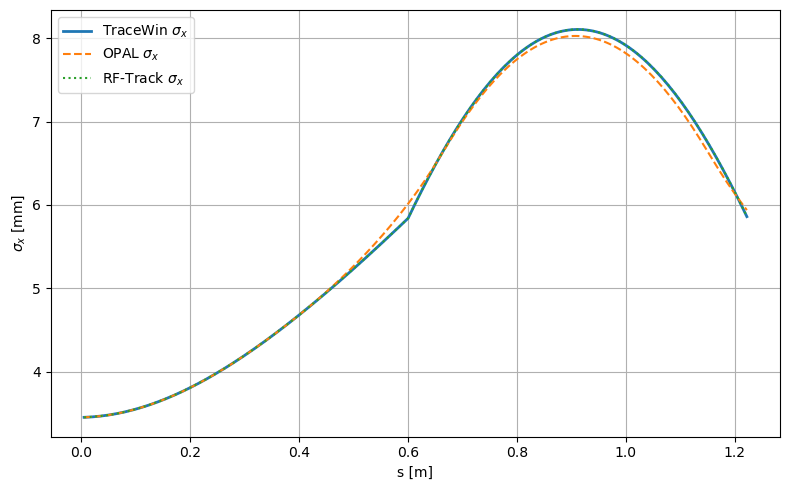

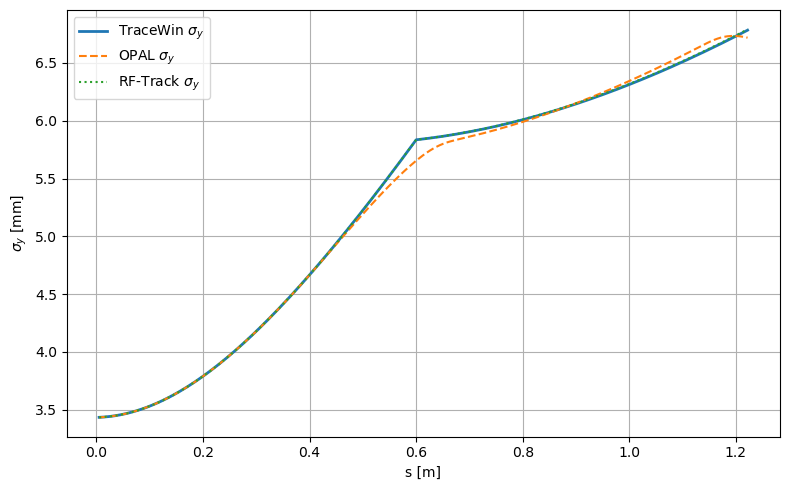

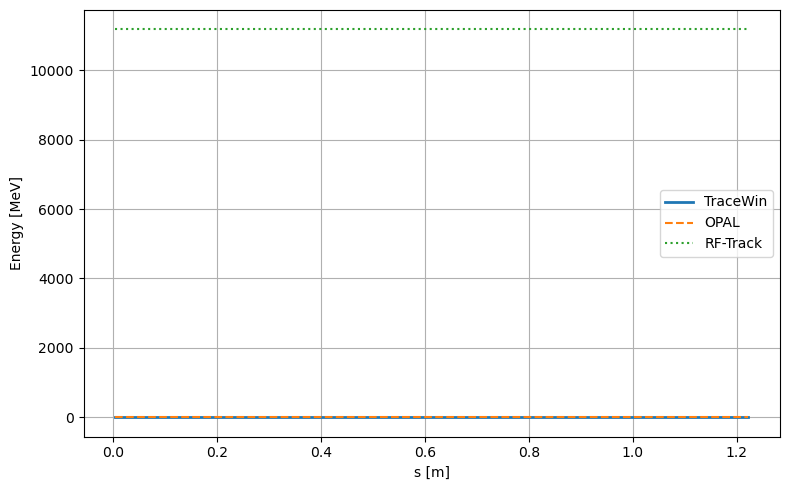

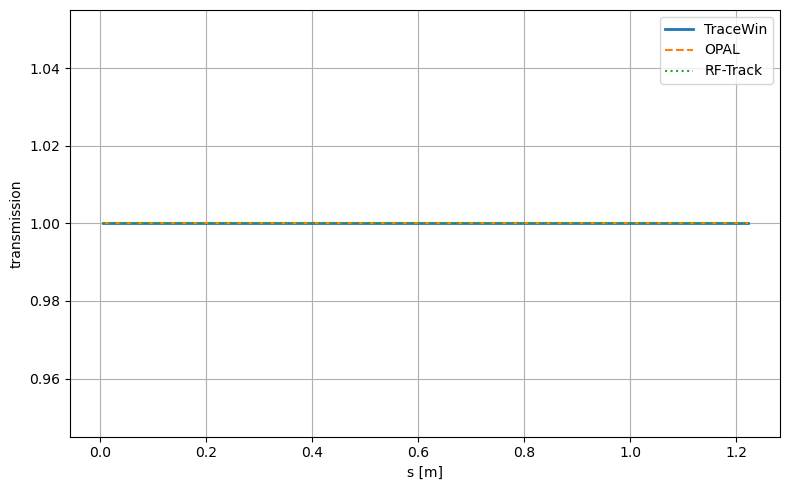

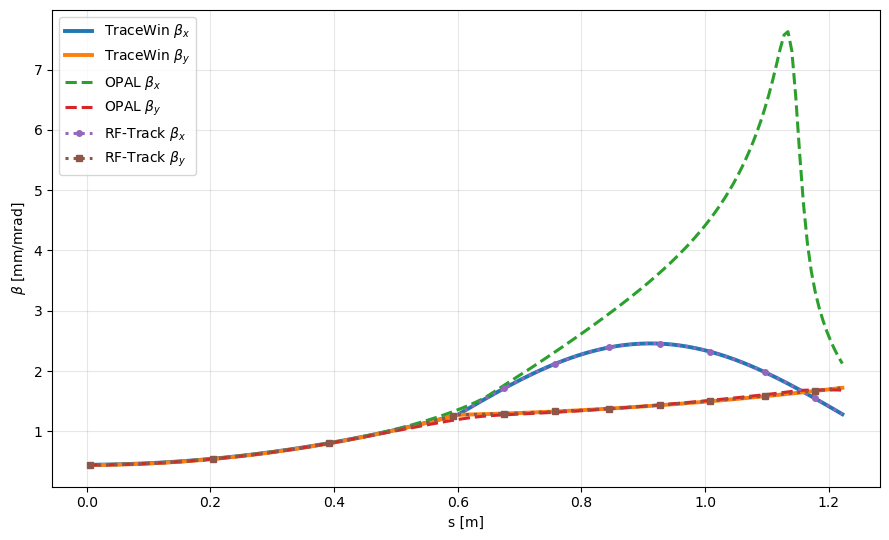

AttributeError: module 'matplotlib.pyplot' has no attribute 'set_ylabel'

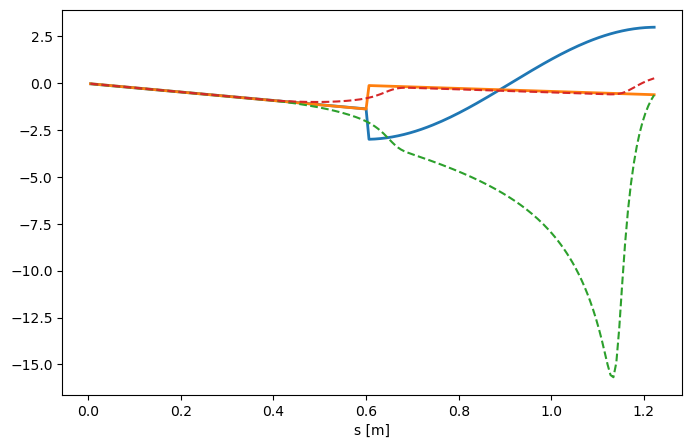

In [ ]:
# Plot rms_x
plt.figure(figsize=(8, 5))
plt.plot(s_common, rms_x_tw_c, label="TraceWin $\\sigma_x$", linewidth=2)
plt.plot(s_common, rms_x_opal_c, "--", label="OPAL $\\sigma_x$")
plt.plot(s_common, rms_x_rf_c, ":", label="RF-Track $\\sigma_x$")
plt.xlabel("s [m]")
plt.ylabel("$\\sigma_x$ [mm]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot rms_y
plt.figure(figsize=(8, 5))
plt.plot(s_common, rms_y_tw_c, label="TraceWin $\\sigma_y$", linewidth=2)
plt.plot(s_common, rms_y_opal_c, "--", label="OPAL $\\sigma_y$")
plt.plot(s_common, rms_y_rf_c, ":", label="RF-Track $\\sigma_y$")
plt.xlabel("s [m]")
plt.ylabel("$\\sigma_y$ [mm]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Error sigma_x
#plt.figure(figsize=(8, 5))
#plt.plot(s_common, err_x_opal, label="OPAL vs TraceWin")
#plt.plot(s_common, err_x_rf, label="RF-Track vs TraceWin")
#plt.axhline(0, color="black", linewidth=0.8)
#plt.xlabel("s [m]")
#plt.ylabel("Relative error $\\sigma_x$ [%]")
#plt.grid(True)
#plt.legend()
#plt.tight_layout()
#plt.show()
#
## Error sigma_y 
#plt.figure(figsize=(8, 5))
#plt.plot(s_common, err_y_opal, label="OPAL vs TraceWin")
#plt.plot(s_common, err_y_rf, label="RF-Track vs TraceWin")
#plt.axhline(0, color="black", linewidth=0.8)
#plt.xlabel("s [m]")
#plt.ylabel("Relative error $\\sigma_y$ [%]")
#plt.grid(True)
#plt.legend()
#plt.tight_layout()
#plt.show()

#Energy
plt.figure(figsize=(8, 5))
plt.plot(s_common, E_tracewin_c, label="TraceWin", linewidth=2)
plt.plot(s_common, E_opal_c, "--", label="OPAL")
plt.plot(s_common, E_rf_c, ":", label="RF-Track")
plt.xlabel("s [m]")
plt.ylabel("Energy [MeV]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Transmission 
plt.figure(figsize=(8, 5))
plt.plot(s_common, T_tw_c, label="TraceWin", linewidth=2)
plt.plot(s_common, T_opal_c, "--", label="OPAL")
plt.plot(s_common, T_rf_c, ":", label="RF-Track")
plt.xlabel("s [m]")
plt.ylabel("transmission")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#beta 
plt.figure(figsize=(9, 5.5))

plt.plot(s_common, beta_x_tw_c,   "-",  lw=2.8, label=r"TraceWin $\beta_x$")
plt.plot(s_common, beta_y_tw_c,   "-",  lw=2.8, label=r"TraceWin $\beta_y$")

plt.plot(s_common, beta_x_opal_c, "--", lw=2.2, label=r"OPAL $\beta_x$")
plt.plot(s_common, beta_y_opal_c, "--", lw=2.2, label=r"OPAL $\beta_y$")

plt.plot(s_common, beta_x_rf_c,   ":",  lw=2.2, marker="o", markevery=40,
         ms=4, label=r"RF-Track $\beta_x$")
plt.plot(s_common, beta_y_rf_c,   ":",  lw=2.2, marker="s", markevery=40,
         ms=4, label=r"RF-Track $\beta_y$")

plt.xlabel("s [m]")
plt.ylabel(r"$\beta$ [mm/mrad]")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

#alpha
plt.figure(figsize=(8, 5))
plt.plot(s_common, alpha_x_rf_c, label="RF-Track $\\alpha_x$", linewidth=2)
plt.plot(s_common, alpha_y_rf_c, label="RF-Track $\\alpha_y$", linewidth=2)
plt.plot(s_common, alpha_x_opal_c, "--", label="OPAL $\\alpha_x$")
plt.plot(s_common, alpha_y_opal_c, "--", label="OPAL $\\alpha_y$")
plt.xlabel("s [m]")
plt.ylabel("$\\alpha$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
## Relative Errors

In [ ]:

err_x_opal = relative_error_percent(rms_x_opal_c, rms_x_tw_c)
err_y_opal = relative_error_percent(rms_y_opal_c, rms_y_tw_c)
err_T_opal = relative_error_percent(T_opal_c, T_tw_c)

err_x_rf = relative_error_percent(rms_x_rf_c, rms_x_tw_c)
err_y_rf = relative_error_percent(rms_y_rf_c, rms_y_tw_c)
err_T_rf = relative_error_percent(T_rf_c, T_tw_c)


print_stats("OPAL vs TraceWin - sigma_x", err_x_opal)
print_stats("OPAL vs TraceWin - sigma_y", err_y_opal)
print_stats("OPAL vs TraceWin - transmission", err_T_opal)

print_stats("RF-Track vs TraceWin - sigma_x", err_x_rf)
print_stats("RF-Track vs TraceWin - sigma_y", err_y_rf)
print_stats("RF-Track vs TraceWin - transmission", err_T_rf)


OPAL vs TraceWin - sigma_x
  mean relative error       = -0.3989 %
  RMS relative error        =  1.0091 %

OPAL vs TraceWin - sigma_y
  mean relative error       = -0.1527 %
  RMS relative error        =  0.8203 %

OPAL vs TraceWin - transmission
  mean relative error       =  0.0000 %
  RMS relative error        =  0.0000 %

RF-Track vs TraceWin - sigma_x
  mean relative error       =  0.0117 %
  RMS relative error        =  0.0171 %

RF-Track vs TraceWin - sigma_y
  mean relative error       =  0.0423 %
  RMS relative error        =  0.0547 %

RF-Track vs TraceWin - transmission
  mean relative error       =  0.0000 %
  RMS relative error        =  0.0000 %
